In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

In [3]:
df = pd.read_csv(
    "../data/processed/cleaned_job_postings.csv"
)

print(df.shape)

(15879, 2)


In [4]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
import joblib

pipeline = joblib.load(
    "../models/fake_job_pipeline.pkl"
)

In [23]:
print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])


In [8]:
y_pred = pipeline.predict(X_test)

In [9]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [11]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3033
           1       0.98      0.30      0.46       143

    accuracy                           0.97      3176
   macro avg       0.97      0.65      0.72      3176
weighted avg       0.97      0.97      0.96      3176



In [12]:
fake_f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print("Fake Job F1-score:", fake_f1)

Fake Job F1-score: 0.45989304812834225


In [13]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.968198992443325


In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[3032    1]
 [ 100   43]]


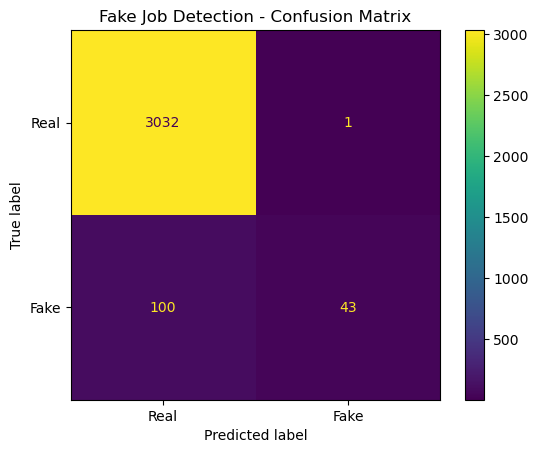

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot()

plt.title("Fake Job Detection - Confusion Matrix")

plt.savefig(
    "../reports/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3033
           1       0.98      0.30      0.46       143

    accuracy                           0.97      3176
   macro avg       0.97      0.65      0.72      3176
weighted avg       0.97      0.97      0.96      3176



In [28]:
from sklearn.metrics import classification_report, f1_score

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label=1
)

print("Random Forest Fake Job F1:", rf_f1)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3033
           1       0.91      0.41      0.56       143

    accuracy                           0.97      3176
   macro avg       0.94      0.70      0.77      3176
weighted avg       0.97      0.97      0.97      3176

Random Forest Fake Job F1: 0.5603864734299517


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        stop_words="english"
    )),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

print(classification_report(
    y_test,
    xgb_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3033
           1       0.97      0.60      0.74       143

    accuracy                           0.98      3176
   macro avg       0.97      0.80      0.87      3176
weighted avg       0.98      0.98      0.98      3176



In [32]:
xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    pos_label=1
)

print("XGBoost Fake Job F1:", xgb_f1)

XGBoost Fake Job F1: 0.7413793103448276


Model comparison

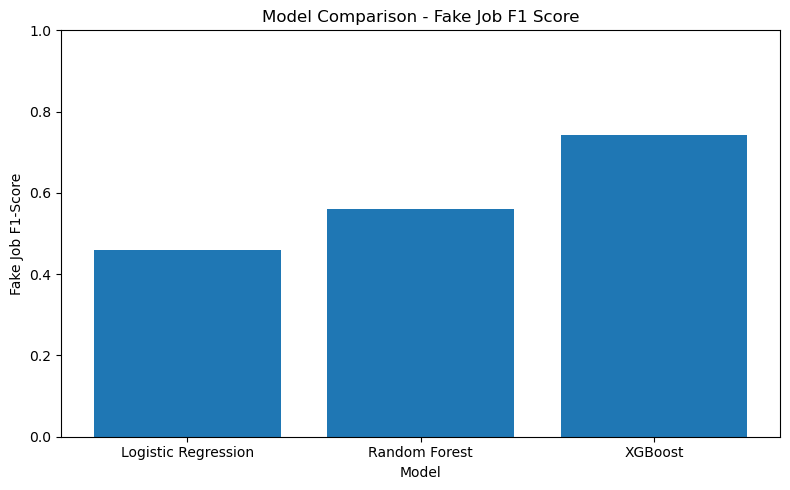

In [33]:
import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

f1_scores = [
    0.46,
    0.5603864743299517,
    0.7413793103448276
]

plt.figure(figsize=(8, 5))

plt.bar(model_names, f1_scores)

plt.xlabel("Model")
plt.ylabel("Fake Job F1-Score")
plt.title("Model Comparison - Fake Job F1 Score")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "../reports/model_comparison.png",
    dpi=300
)

plt.show()

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(cm)

[[3030    3]
 [  57   86]]


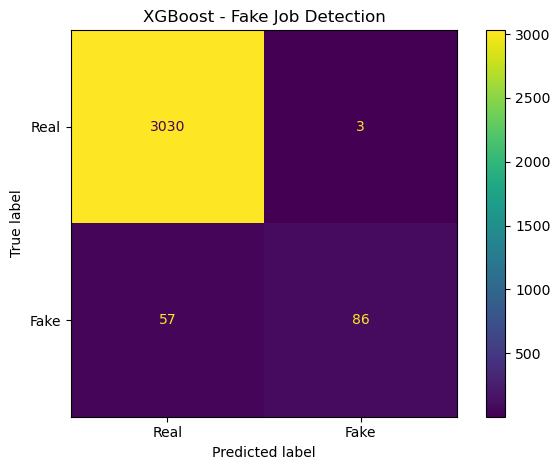

In [35]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot()

plt.title("XGBoost - Fake Job Detection")

plt.tight_layout()

plt.savefig(
    "../reports/confusion_matrix.png",
    dpi=300
)

plt.show()

Feature importance for XGBoost

In [36]:
tfidf = xgb_pipeline.named_steps["tfidf"]

feature_names = tfidf.get_feature_names_out()

In [37]:
model = xgb_pipeline.named_steps["clf"]

importances = model.feature_importances_

In [38]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [39]:
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

In [40]:
print(
    feature_importance.head(20)
)

             feature  importance
1560      encouraged    0.033291
1614           entry    0.028620
187   administrative    0.026917
3206       partnered    0.026356
1465            earn    0.018901
67               400    0.018325
2068         growing    0.015022
3793      represents    0.013504
2009    geographical    0.013190
4887         website    0.012058
1                000    0.011723
1056     contracting    0.009502
4025         seeking    0.009291
954         complete    0.007125
4950           world    0.007003
108           access    0.006866
2163        holidays    0.006808
3449          prices    0.006393
921       commitment    0.006305
2636            link    0.006287


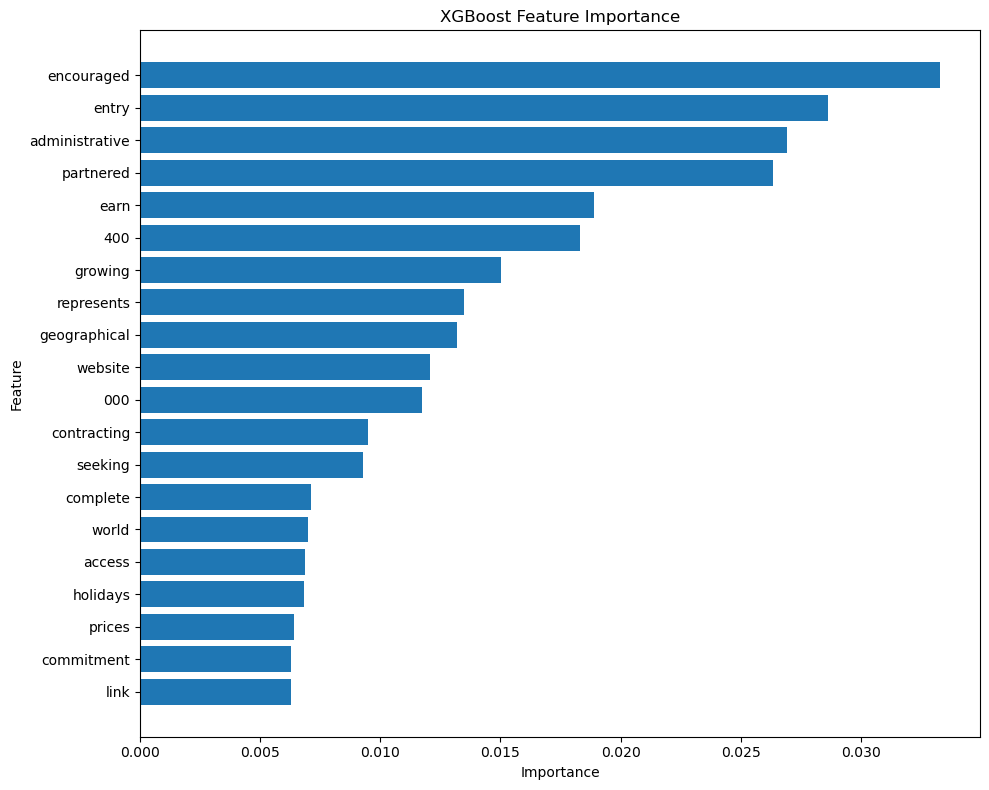

In [41]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig(
    "../reports/feature_importance.png",
    dpi=300
)

plt.show()

In [42]:
joblib.dump(
    xgb_pipeline,
    "../models/fake_job_pipeline.pkl"
)

['../models/fake_job_pipeline.pkl']

In [43]:
import os

print(
    os.path.exists(
        "../models/fake_job_pipeline.pkl"
    )
)

True
